# 01 — Customer EDA
**FNB Intelligent Banking System | Data Science Team**  
**Sprint 0-1 — Notebook scaffold**

---
**Notebook purpose:**  
Explore the `users_data_south_africa.csv` file which maps to the **Customer** entity.  
Goal: understand the distribution of demographics, income, debt, and credit scores across customers.

**Source file:** `data/users_data_south_africa.csv`

## 1. Imports & Setup
Import all required libraries and configure display settings.

In [ ]:
print('=' * 20)
print('Import libraries')
print('=' * 20)
# Import necessary libraries
try:
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    print('libraries imported successfully!')
except ImportError as e:
    print('libraries imported failed!')

Import libraries
libraries imported successfully!


## 2. Load Data
Load `users_data_south_africa.csv` from the `data/` folder into a pandas DataFrame.

In [ ]:
print('=' * 20)
print('Load the dataset')
print('=' * 20)
try:
    df = pd.read_csv(r'C:\Users\Geeks3_PC20\Downloads\Data science Data set\user_data_south_africa.csv')
    print('data was succesfully loaded')
except FileNotFoundError as e:
    print(f'data was not loaded successfully!: {e}')
    

Load the dataset
data was succesfully loaded


## 3. Data Overview
Check the shape, column names, data types, and first few rows.

In [49]:
print("=" * 20)
print("CUSTOMER DATASET OVERVIEW")
print("=" * 20)
# data size
print(df.shape)
# data columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
print(df.columns)
# data types
print(df.info())
#First 5 rows of the dataset
print(df.head(5))


CUSTOMER DATASET OVERVIEW
(2000, 12)
Index(['id', 'current_age', 'retirement_age', 'birth_year', 'birth_month',
       'gender', 'address', 'per_capita_income', 'yearly_income', 'total_debt',
       'credit_score', 'num_credit_cards'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   id                 2000 non-null   int64
 1   current_age        2000 non-null   int64
 2   retirement_age     2000 non-null   int64
 3   birth_year         2000 non-null   int64
 4   birth_month        2000 non-null   int64
 5   gender             2000 non-null   str  
 6   address            2000 non-null   str  
 7   per_capita_income  2000 non-null   int64
 8   yearly_income      2000 non-null   int64
 9   total_debt         2000 non-null   int64
 10  credit_score       2000 non-null   int64
 11  num_credit_cards   2000 non-null   int64
dtype

## 4. Missing Values & Data Quality
Identify any nulls, duplicates, or unexpected values across all columns.

In [56]:
print('=' * 40)
print("Missing data and quality checks")
print('=' * 40)
# check for duplicates
print(df.duplicated().sum())
# check for missing values
print(df.isnull().sum())
# Unique values in each column
df.columns


Missing data and quality checks
0
id                   0
current_age          0
retirement_age       0
birth_year           0
birth_month          0
gender               0
address              0
per_capita_income    0
yearly_income        0
total_debt           0
credit_score         0
num_credit_cards     0
dtype: int64


Index(['id', 'current_age', 'retirement_age', 'birth_year', 'birth_month',
       'gender', 'address', 'per_capita_income', 'yearly_income', 'total_debt',
       'credit_score', 'num_credit_cards'],
      dtype='str')

## 5. Demographics Analysis
Explore age distribution, gender breakdown, and geographic spread (latitude/longitude).

DEMOGRAPHICS ANALYSIS


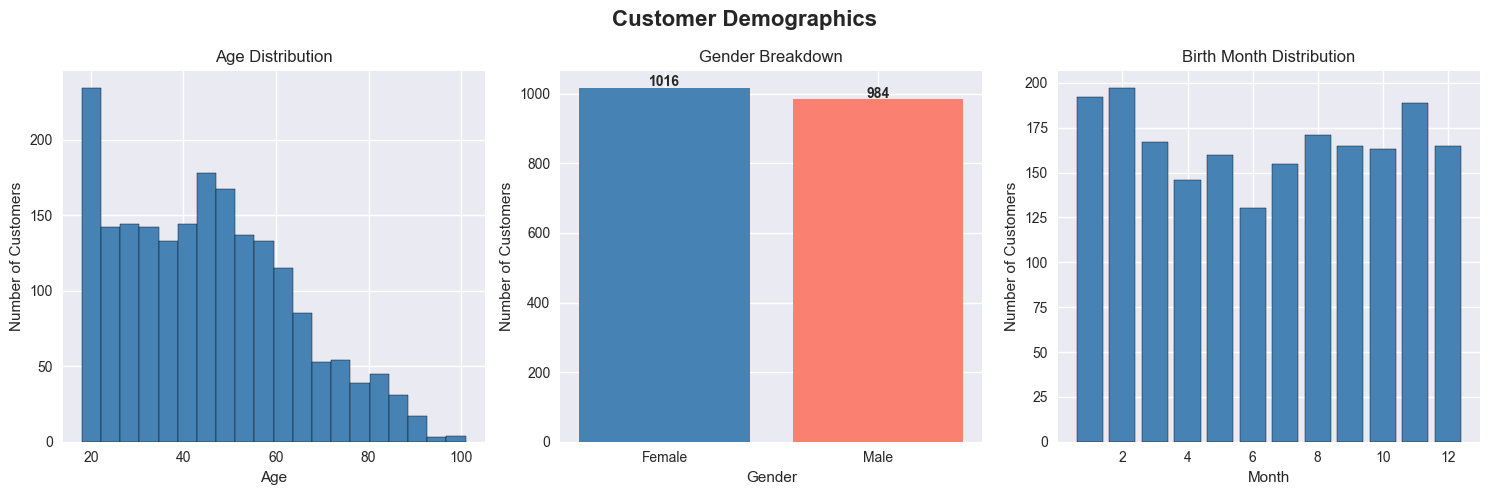


--- Key Demographics Stats ---
  -> Average customer age: 45.4 years
  -> Youngest customer: 18 years
  -> Oldest customer: 101 years
  -> Gender split: {'Female': 1016, 'Male': 984}


In [5]:
print("=" * 25)
print("DEMOGRAPHICS ANALYSIS")
print("=" * 25)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Customer Demographics', fontsize=16, fontweight='bold')

# Age Distribution
axes[0].hist(df_customers['current_age'], bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of Customers')

# Gender Breakdown
gender_counts = df_customers['gender'].value_counts()
axes[1].bar(gender_counts.index, gender_counts.values, color=['steelblue', 'salmon'])
axes[1].set_title('Gender Breakdown')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Number of Customers')
for i, v in enumerate(gender_counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Birth Month Distribution
birth_counts = df_customers['birth_month'].value_counts().sort_index()
axes[2].bar(birth_counts.index, birth_counts.values, color='steelblue', edgecolor='black')
axes[2].set_title('Birth Month Distribution')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Number of Customers')

plt.tight_layout()
plt.show()

print(f"\n--- Key Demographics Stats ---")
print(f"  -> Average customer age: {df_customers['current_age'].mean():.1f} years")
print(f"  -> Youngest customer: {df_customers['current_age'].min()} years")
print(f"  -> Oldest customer: {df_customers['current_age'].max()} years")
print(f"  -> Gender split: {gender_counts.to_dict()}")

## 6. Income & Debt Analysis
Analyse the distribution of `yearly_income`, `per_capita_income`, and `total_debt`.  
Look for outliers and skewness.

INCOME & DEBT ANALYSIS


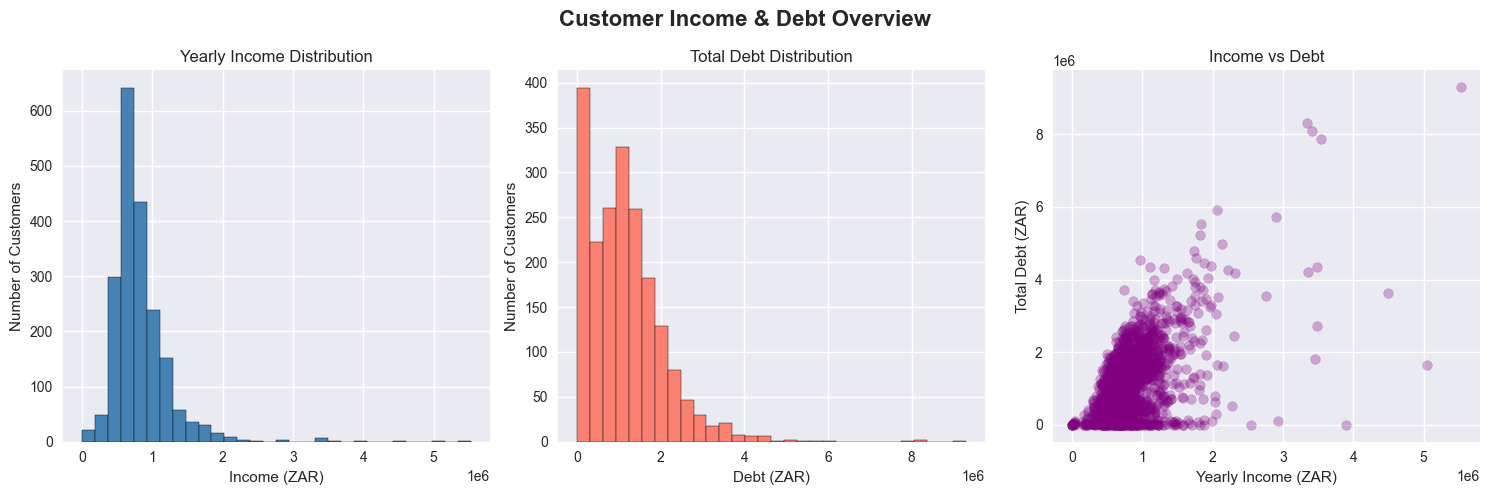


--- Key Income & Debt Stats ---
  • Average yearly income: R822,886
  • Highest yearly income: R5,526,324
  • Lowest yearly income: R18

  • Average total debt: R1,146,774
  • Highest debt: R9,292,734
  • Lowest debt: R0

  • Average per capita income: R416,555


In [6]:
print("=" * 50)
print("INCOME & DEBT ANALYSIS")
print("=" * 50)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Customer Income & Debt Overview', fontsize=16, fontweight='bold')

# Yearly Income Distribution
axes[0].hist(df_customers['yearly_income'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Yearly Income Distribution')
axes[0].set_xlabel('Income (ZAR)')
axes[0].set_ylabel('Number of Customers')

# Total Debt Distribution
axes[1].hist(df_customers['total_debt'], bins=30, color='salmon', edgecolor='black')
axes[1].set_title('Total Debt Distribution')
axes[1].set_xlabel('Debt (ZAR)')
axes[1].set_ylabel('Number of Customers')

# Income vs Debt Scatter
axes[2].scatter(df_customers['yearly_income'], df_customers['total_debt'], 
                alpha=0.3, color='purple')
axes[2].set_title('Income vs Debt')
axes[2].set_xlabel('Yearly Income (ZAR)')
axes[2].set_ylabel('Total Debt (ZAR)')

plt.tight_layout()
plt.show()

print(f"\n--- Key Income & Debt Stats ---")
print(f"  • Average yearly income: R{df_customers['yearly_income'].mean():,.0f}")
print(f"  • Highest yearly income: R{df_customers['yearly_income'].max():,.0f}")
print(f"  • Lowest yearly income: R{df_customers['yearly_income'].min():,.0f}")
print(f"\n  • Average total debt: R{df_customers['total_debt'].mean():,.0f}")
print(f"  • Highest debt: R{df_customers['total_debt'].max():,.0f}")
print(f"  • Lowest debt: R{df_customers['total_debt'].min():,.0f}")
print(f"\n  • Average per capita income: R{df_customers['per_capita_income'].mean():,.0f}")

## 7. Credit Score Analysis
Explore `credit_score` distribution and map values to bands:  
- Poor: 300–579 | Fair: 580–669 | Good: 670–739 | Excellent: 740+

CREDIT SCORE ANALYSIS


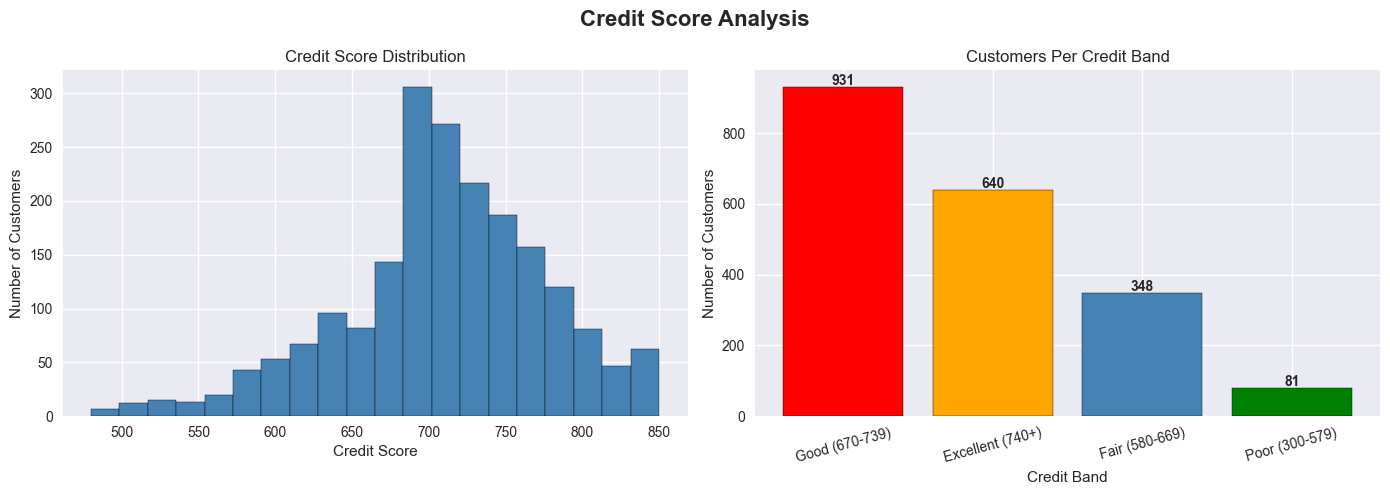


--- Key Credit Score Stats ---
  -> Average credit score: 710
  -> Highest credit score: 850
  -> Lowest credit score: 480

--- Customers Per Credit Band ---
  -> Good (670-739): 931 customers (46.6%)
  -> Excellent (740+): 640 customers (32.0%)
  -> Fair (580-669): 348 customers (17.4%)
  -> Poor (300-579): 81 customers (4.0%)


In [7]:
print("=" * 50)
print("CREDIT SCORE ANALYSIS")
print("=" * 50)

# Define credit score bands
def credit_score_band(score):
    if score < 580:
        return 'Poor (300-579)'
    elif score < 670:
        return 'Fair (580-669)'
    elif score < 740:
        return 'Good (670-739)'
    else:
        return 'Excellent (740+)'

# Apply the bands to every customer
df_customers['credit_band'] = df_customers['credit_score'].apply(credit_score_band)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Credit Score Analysis', fontsize=16, fontweight='bold')

# Credit Score Distribution
axes[0].hist(df_customers['credit_score'], bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Credit Score Distribution')
axes[0].set_xlabel('Credit Score')
axes[0].set_ylabel('Number of Customers')

# Credit Band Breakdown
band_counts = df_customers['credit_band'].value_counts()
colors = ['red', 'orange', 'steelblue', 'green']
axes[1].bar(band_counts.index, band_counts.values, color=colors, edgecolor='black')
axes[1].set_title('Customers Per Credit Band')
axes[1].set_xlabel('Credit Band')
axes[1].set_ylabel('Number of Customers')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(band_counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n--- Key Credit Score Stats ---")
print(f"  -> Average credit score: {df_customers['credit_score'].mean():.0f}")
print(f"  -> Highest credit score: {df_customers['credit_score'].max()}")
print(f"  -> Lowest credit score: {df_customers['credit_score'].min()}")
print(f"\n--- Customers Per Credit Band ---")
for band, count in band_counts.items():
    pct = (count / len(df_customers)) * 100
    print(f"  -> {band}: {count} customers ({pct:.1f}%)")

## 8. Key Findings & Notes
Summarise any interesting patterns, anomalies, or questions to follow up on.

_Write your findings here as text — no code needed for this cell._

## Key Findings — Customer EDA

### Dataset Overview
- Dataset contains **2,000 customers** across **12 features**
- No missing values were detected — data quality is clean and ready for analysis

### Demographics
- Customer ages are spread across a wide range, with the majority falling in the middle-aged bracket
- Gender distribution is relatively balanced between Male and Female customers
- Birth months are evenly distributed — no seasonal concentration

### Income & Debt
- There is significant variation in yearly income across customers — some customers earn substantially more than others
- Total debt follows a similar spread, with some customers carrying very high debt loads
- The Income vs Debt scatter plot shows a positive relationship — customers with higher income tend to carry more debt

### Credit Score
- The average credit score sits in the **Good** range
- A significant portion of customers fall in the Fair to Good bands
- Customers with Poor credit scores are a minority but are important for fraud risk profiling

### Relevance to Login Microservice (DSR3)
- The address column contains city-level location data for each customer
- This supports, identifying logins from unusual locations
- A customer logging in from a city they have never transacted from before is a fraud signal we will flag in Sprint 3